# Gene DEA PD vs Ctl

This markdown runs gene differential expression analysis in each cluster. 

- The analysis is not performed in genes located in sex chromosomes. 
- Log fold changes are also calculated as stable log fold changes (mean in PD / mean in Ctl) using `compute_logfc_pseudocount_from_layer()`.
- Results can be found in the clean data folder.

## Loading libraries and data

In [1]:
import scanpy as sc
import pandas as pd
import statistics
import sys
import getopt
import os
import matplotlib.pyplot as mp
import anndata as ad
import time
import numpy as np
import re

sc.settings.figdir = "../results/figures/"
print(sc.__version__)
adata = ad.read_h5ad("h5s/ASAP_adata_umap_integration_celltypes_wraw.h5")

1.10.1


## Subset counts to genes not in sex chromosomes.

In [2]:
chrX = pd.read_csv("/scale/gr01/shared/jjakobsson/processed/ASAP_snRNA_spatial_invitro/data/tables/chrX_genes.txt", header=None)
chrY = pd.read_csv("/scale/gr01/shared/jjakobsson/processed/ASAP_snRNA_spatial_invitro/data/tables/chrY_genes.txt", header=None)
sex_genes = [i for i in adata.var_names.tolist() if i in chrX[0].tolist() or i in chrY[0].tolist()]
keep_genes = adata.var_names.tolist()
keep_genes = [i for i in keep_genes if i not in sex_genes]
len(keep_genes)

adata_subset = adata[:, keep_genes].copy()

## A handy metadata variable to group nuclei into later on.

In [3]:
adata_subset.obs["region_dx_leiden"] = adata_subset.obs['region'].astype(str) + "_" + adata_subset.obs['dx'].astype(str) + "_" + adata_subset.obs['leiden'].astype(str) 

## `compute_logfc_pseudocount_from_layer()` 

Computes stable log2 fold changes between the scaled (by default, but you can specify the layer) counts in two groups. All genes at once.

In [4]:
def compute_logfc_pseudocount_from_layer(adata, groupby, group1, group2, layer="scaled", pseudocount=1):
    def get_mean_expr(adata, group, layer):
        X = adata[adata.obs[groupby] == group].layers[layer]
        # Convert sparse to dense numpy array if needed
        if hasattr(X, "A"):
            X = X.A
        elif hasattr(X, "toarray"):
            X = X.toarray()
        return np.mean(X, axis=0)

    mean1 = get_mean_expr(adata, group1, layer)
    mean2 = get_mean_expr(adata, group2, layer)
    print(mean1)
    print(mean2)
    logfc = np.log2((mean1 + pseudocount) / (mean2 + pseudocount))
    genes = adata.var_names
    return pd.Series(logfc, index=genes)

## Main loop for DEA

Looping per region, per cluster (0:7). 
We use the rank_genes_groups (wilcox tests) to calculate statistics (PD vs Ctl). However, logfoldchanges many times are missing using this function, thus, we also calculate stable logfoldchanges (based on the group mean). 

Please note that these statistics are just validation of our pseudobulk analysis. 

SN
[-0.16346972 -0.2089843  -0.02644676 ... -0.33222172 -0.2469228
 -0.22068377]
[ 0.96541464 -0.2089843  -0.02644676 ...  0.23524323 -0.2469228
 -0.10558257]
False


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


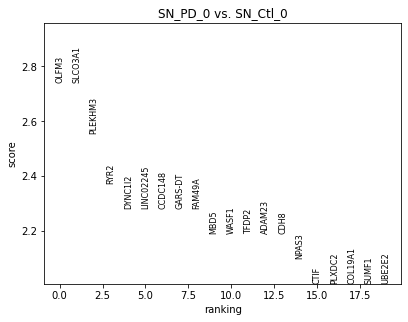

0


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


[ 0.00698161 -0.12110586  0.03602307 ...  0.2993425  -0.03456575
 -0.0507292 ]
[-0.00708805  0.00770362 -0.00441066 ...  0.2802667  -0.05821154
 -0.07118863]
False


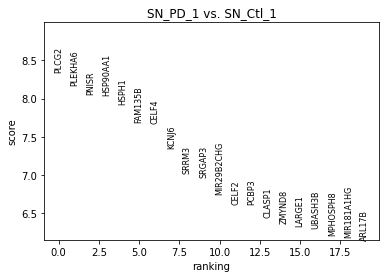

1


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


[-0.10924479 -0.19972308 -0.02275259 ... -0.18745834 -0.07736096
 -0.15121211]
[-0.13211559 -0.19829045 -0.02376353 ... -0.2846226  -0.07144138
 -0.21705203]
False


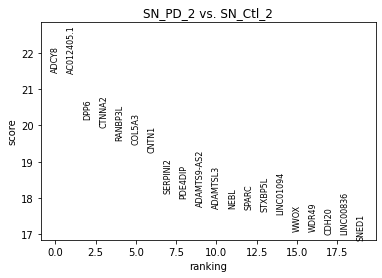

2


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


[-0.14724807 -0.2074634  -0.01990448 ...  0.01662546 -0.07041886
 -0.16699459]
[-0.14872587 -0.1965287  -0.0196357  ... -0.15470749 -0.06090765
 -0.26420277]
False


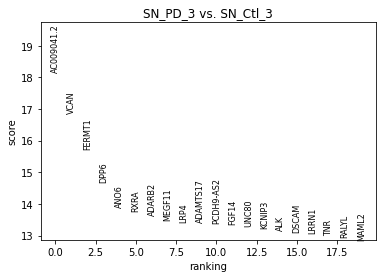

3


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


[ 0.0232675  -0.0151139  -0.0264454  ... -0.07764067  0.17482738
 -0.09991797]
[-0.04053374 -0.06928166 -0.0264471  ... -0.2145319   0.16126943
 -0.14098293]
False


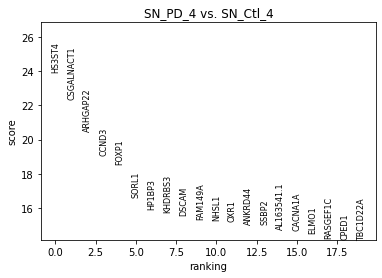

4


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


[ 0.15336566  0.05283483 -0.02477664 ... -0.02367102 -0.13796219
  0.04874918]
[ 0.06710901 -0.00499852 -0.02434099 ... -0.2021294  -0.15194587
 -0.11928036]
False


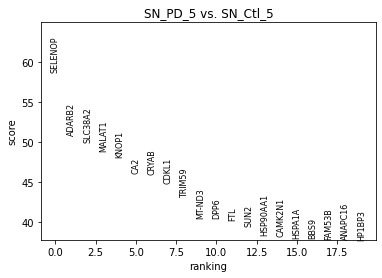

5
[ 0.00731246 -0.04537141 -0.02644681 ... -0.09191958  0.16201492
 -0.04910463]
[ 0.02570754 -0.02958624 -0.02644681 ... -0.04344466  0.23891509
 -0.08731506]
False


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


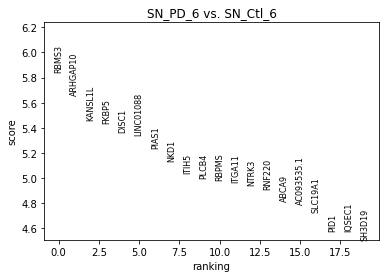

6
PUT


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


[0.14394084 0.4141876  0.02109204 ... 0.3491685  0.04479163 0.21281151]
[0.18452525 0.48045444 0.07180507 ... 0.31182975 0.10412277 0.36962044]
False


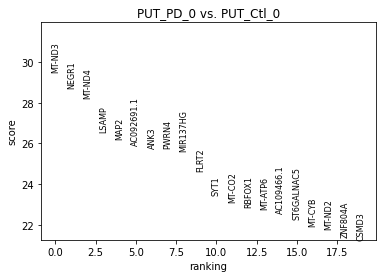

0


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


[0.07280084 0.21071729 0.01679387 ... 0.43170363 0.1363106  0.18273272]
[-0.01469895  0.12965852 -0.00635373 ...  0.2910782   0.18296492
  0.01956029]
False


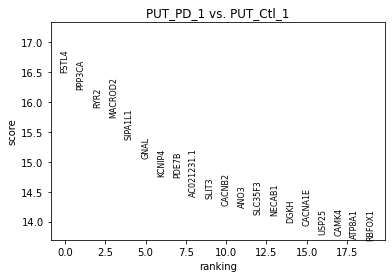

1


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


[-0.08917059 -0.19621627 -0.01313845 ... -0.0868187  -0.06862574
 -0.02981712]
[-0.10678098 -0.18150917 -0.01190323 ... -0.19430962 -0.03778121
 -0.04066525]
False


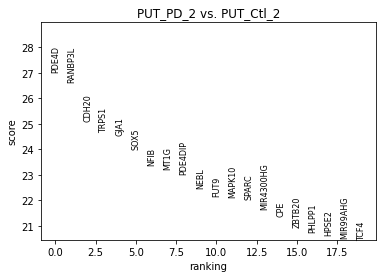

2


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


[-0.1528896  -0.20177476 -0.01343409 ... -0.02359973 -0.06177018
 -0.12659843]
[-0.14540575 -0.18606307 -0.0153862  ... -0.05411526 -0.08638676
 -0.1100165 ]
False


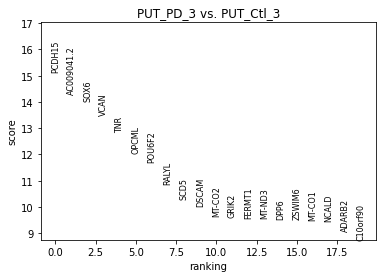

3


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


[-0.01349091 -0.03336742 -0.0240328  ... -0.10138793  0.12891315
 -0.0687663 ]
[-0.01732    -0.00543421 -0.026447   ... -0.18282709  0.20084552
  0.01762711]
False


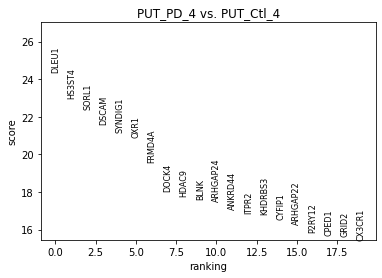

4


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


[ 0.01340452 -0.06862405 -0.02597525 ... -0.14569953 -0.17546655
 -0.10660026]
[-0.00308999 -0.04225125 -0.02644764 ... -0.20352183 -0.18783037
 -0.09792618]
False


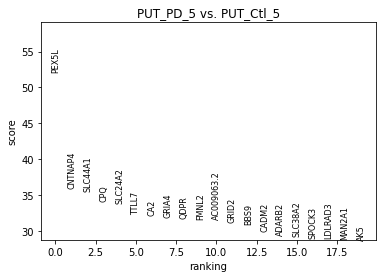

5
[-0.05250128  0.10812756 -0.02644681 ... -0.14687224  0.10618
 -0.17880784]
[-0.07196139  0.01991698 -0.02644679 ... -0.18714602  0.22168662
 -0.14837366]
False


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


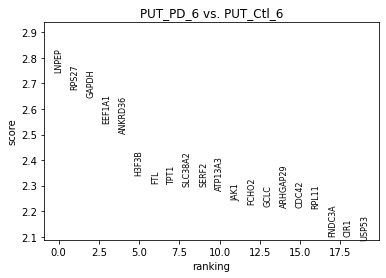

6
PFC


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


[ 0.07443454  0.4441857  -0.00638847 ...  0.6304295   0.7214295
  0.36439136]
[ 0.06309929  0.4945082  -0.00332888 ...  0.58153874  0.5708719
  0.337907  ]
False


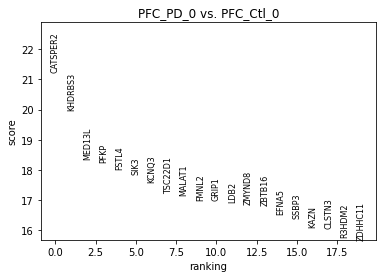

0


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


[ 0.01856058  0.08768371 -0.01731519 ...  0.5185542   0.28878868
  0.18088767]
[-0.01792336  0.09106628 -0.01324003 ...  0.5153049   0.26484585
  0.18409742]
False


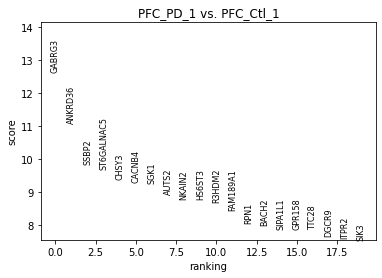

1


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


[-0.10358486 -0.19634457 -0.01579709 ... -0.10772916 -0.10022087
  0.00695719]
[-0.12596577 -0.19249032 -0.0202959  ... -0.0972391  -0.07050923
  0.01693432]
False


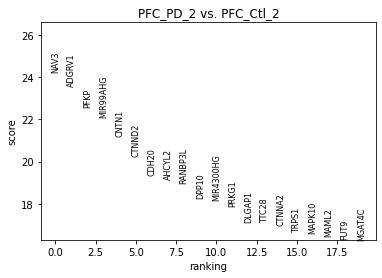

2


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


[-0.12663239 -0.20115659 -0.00557998 ...  0.02353557 -0.01298456
 -0.01643328]
[-0.13257441 -0.18422766 -0.02644709 ...  0.07379699  0.00642192
 -0.00734996]
False


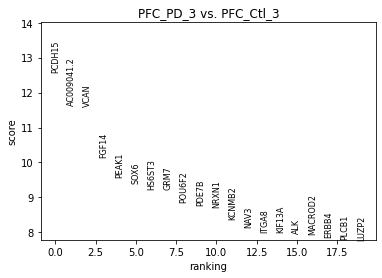

3


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


[-0.09597142 -0.09101555 -0.02190202 ... -0.15322487  0.08924325
 -0.05984038]
[-0.08596812 -0.08630434 -0.026447   ... -0.20331728  0.1774882
 -0.09204382]
False


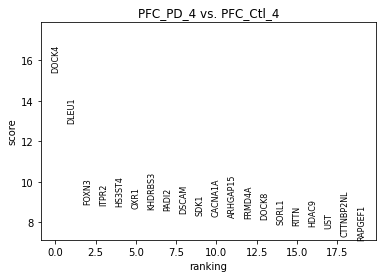

4


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


[ 0.02521094 -0.0123999  -0.02514165 ... -0.098501   -0.14980218
  0.01249327]
[ 0.02621373  0.00682537 -0.02373631 ... -0.13727656 -0.12878369
  0.01762343]
False


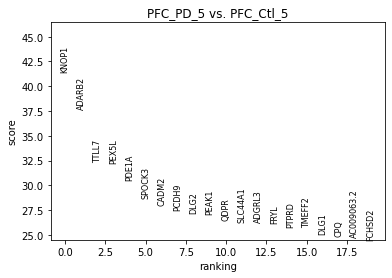

5


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


[ 0.02773372 -0.09539429 -0.02644679 ... -0.0644701   0.10831001
 -0.15333787]
[-0.05199271 -0.03814326 -0.02644671 ... -0.23350482  0.09331427
 -0.2274928 ]
False


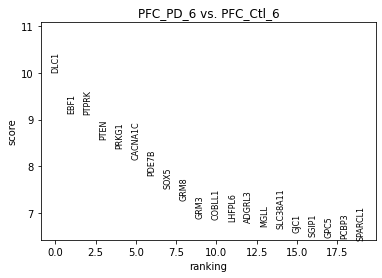

6
AMY


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


[ 0.09972166  0.77189964 -0.0160731  ...  0.69553334  0.7500026
  0.3680488 ]
[0.08837976 0.7515028  0.02717051 ... 0.66949093 0.4821195  0.28371873]
False


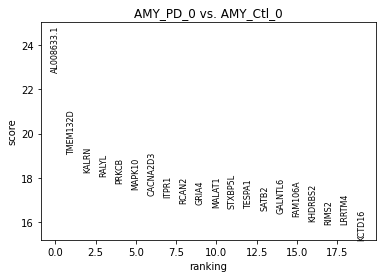

0


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


[-0.07188804 -0.05559817 -0.02123646 ...  0.07211784  0.00141558
 -0.22334816]
[-0.01623851  0.25182033 -0.02120311 ...  0.6658113   0.14733745
  0.20293765]
False


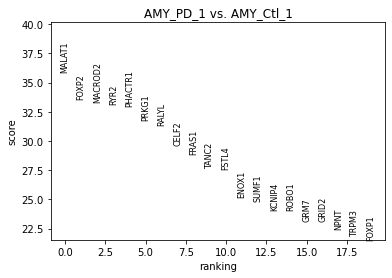

1


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


[-0.11134652 -0.19542792 -0.0221431  ... -0.23307182 -0.11562535
 -0.17656979]
[-0.11173828 -0.156521   -0.01203781 ... -0.0543827   0.00753308
  0.14990473]
False


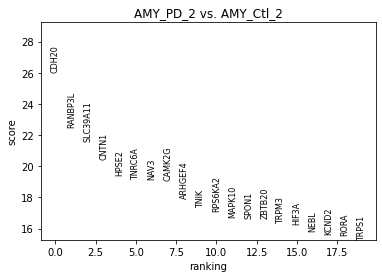

2


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


[-0.13388829 -0.19749762 -0.01515162 ...  0.0168938  -0.08524233
 -0.11867119]
[-0.13295627 -0.18905202 -0.02644677 ...  0.14884545  0.01881503
  0.03810457]
False


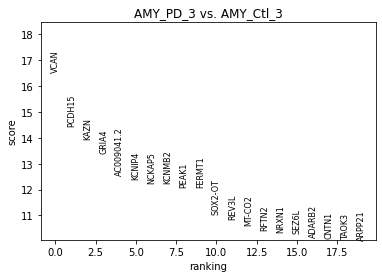

3


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


[-0.04006673 -0.04255928 -0.02644658 ... -0.15378065  0.09384646
 -0.13310447]
[-0.05350522 -0.06647537 -0.02644701 ... -0.1293806   0.32998118
  0.05990584]
False


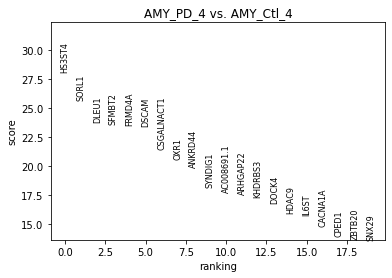

4


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


[ 0.00261379 -0.04677714 -0.02564901 ... -0.12190206 -0.16688505
 -0.08520544]
[ 0.03292924 -0.01729856 -0.02511787 ... -0.05819789 -0.1658817
  0.06266454]
False


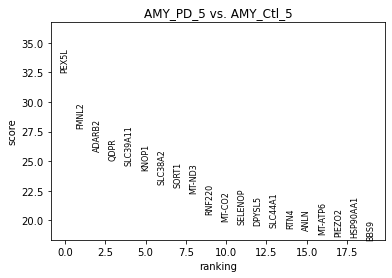

5
[-0.12619671 -0.06593911 -0.0264468  ... -0.22562458  0.24429573
 -0.17488126]
[-0.09195539 -0.12761582 -0.02644681 ... -0.13102536  0.34392232
 -0.18169467]
False


/usr/local/lib/python3.10/dist-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


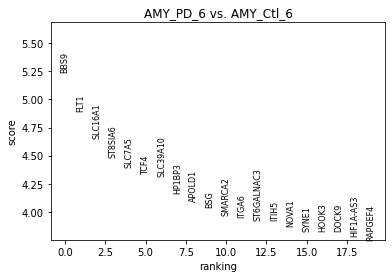

6


In [11]:
leiden_dea = {}
for r in ["SN", "PUT", "PFC", "AMY"]:
    leiden_dea[r] = {}
    print(r)
    for i in [str(i) for i in list(range(0,7))]:
        pd_name = r + "_PD_" + i
        ctl_name = r + "_Ctl_" + i
        key_name = "wilcoxon_wosexchr_" + r + "_PD_" + i
        sc.tl.rank_genes_groups(adata_subset, groupby = 'region_dx_leiden', groups = [pd_name], reference = ctl_name, method="wilcoxon", key_added = key_name)
        leiden_dea[r][i] = sc.get.rank_genes_groups_df(adata_subset, group = pd_name, key=key_name)
        leiden_dea[r][i].index = leiden_dea[r][i].names
        leiden_dea[r][i]["genes"] = leiden_dea[r][i].names
        if "names" in leiden_dea[r][i].columns:
            leiden_dea[r][i] = leiden_dea[r][i].drop(columns=["names"])
        # Compute the stable LFCs
        stable_logfc = compute_logfc_pseudocount_from_layer(adata_subset, groupby="region_dx_leiden", group1=pd_name, group2=ctl_name, layer = "scaled", pseudocount = 10)
        leiden_dea[r][i] = leiden_dea[r][i].merge(stable_logfc.rename("stable_logfoldchange"), left_on="names", right_index=True, how="left")
        
        print("ACSL4" in leiden_dea[r][i].index.tolist()) # Shouldn't be there (chrX)
        filename = "_" + r + "_wosexchrs_" + i + ".pdf"
        sc.pl.rank_genes_groups(adata_subset, key=key_name, save = filename)
        file = "../results/tables/asap_dea_PD_" + r + "_wosexchrs_" + i + ".csv"
        leiden_dea[r][i].to_csv(path_or_buf = file, index = False)
        print(i)
        